In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
ROOT=Path.cwd().parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

# Load cleaned data
df = pd.read_csv(DATA_PROCESSED / 'ads_cleaned.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Platforms: {df['channel_used'].unique()}")

Loaded: 300,000 rows x 25 cols
Platforms: ['Instagram' 'Facebook' 'Pinterest' 'Twitter']


In [4]:
#Overall funnel
total_impressions=df['impressions'].sum()
total_clicks=df['clicks'].sum()
total_conversions=df['conversions'].sum()

impressions_to_clicks=(total_clicks/total_impressions*100)
click_to_conversion=(total_conversions/total_clicks*100)
overall_conversion=(total_conversions/total_impressions*100)

print(f'Impressions:{total_impressions:>12,.0f}')
print(f'Clicks: {total_clicks:>12,.0f}({impressions_to_clicks:.2f}% of impressions)')
print(f'Conversions:{total_conversions:>12,.0f} ({click_to_conversion:.2f}% of clicks)')
print(f'Overall conversion rate:{overall_conversion:.4f}%')

#Funnel by platform
funnel_by_platform=df.groupby('channel_used').agg(
    impressions=('impressions','sum'),
    clicks=('clicks','sum'),
    conversions=('conversions','sum')
).reset_index()

funnel_by_platform['ctr']=(funnel_by_platform['clicks']/funnel_by_platform['impressions']*100).round(3)
funnel_by_platform['cvr']=(funnel_by_platform['conversions']/funnel_by_platform['clicks']*100).round(3)
funnel_by_platform['dropoff']=(100-funnel_by_platform['cvr']).round(1)

print(funnel_by_platform.to_string(index=False))

Impressions:16,810,270,916
Clicks: 5,446,101,111(32.40% of impressions)
Conversions: 436,014,024 (8.01% of clicks)
Overall conversion rate:2.5937%
channel_used  impressions     clicks  conversions    ctr   cvr  dropoff
    Facebook   4617307456 1520264076    121633208 32.925 8.001     92.0
   Instagram   4602504047 1515298729    121035080 32.923 7.988     92.0
   Pinterest   2987239617  894768249     71598728 29.953 8.002     92.0
     Twitter   4603219796 1515770057    121747008 32.928 8.032     92.0


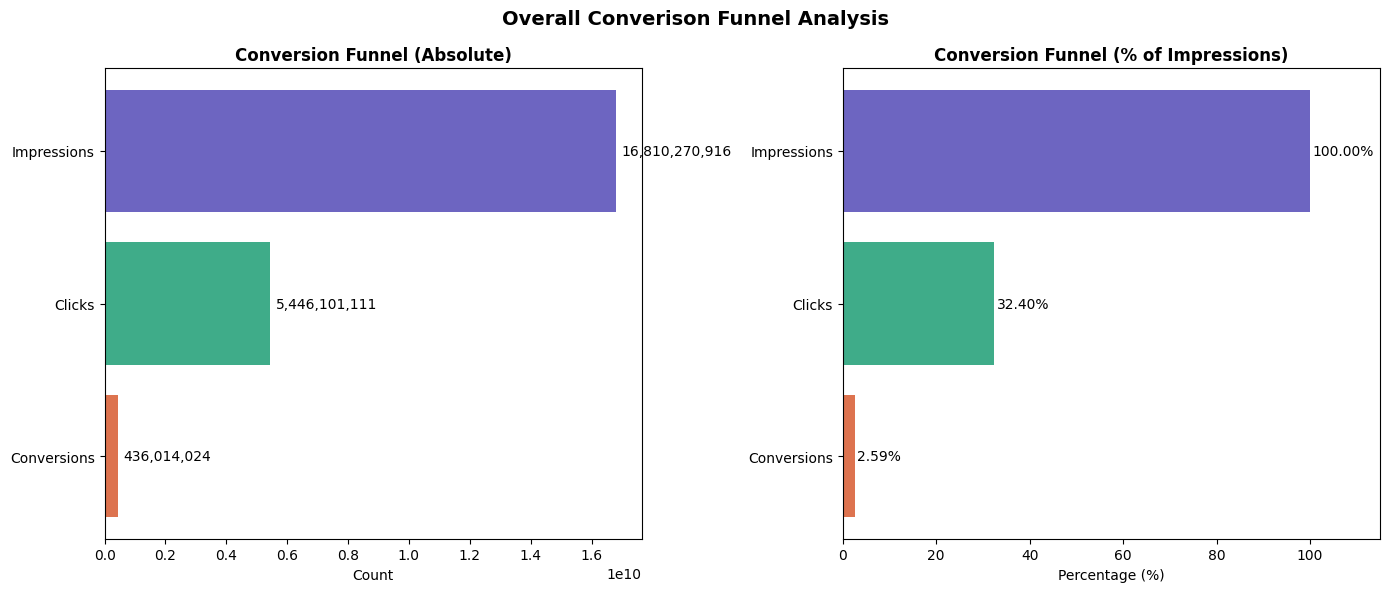

In [7]:
#Funnel Waterfall Chart
stages=['Impressions','Clicks','Conversions']
values=[total_impressions,total_clicks,total_conversions]

#Normalize to percentage of impressions
pct_values=[100,impressions_to_clicks,overall_conversion]
fig,axes=plt.subplots(1,2,figsize=(14,6))

#Left absolute funnel
colors = ['#534AB7', '#1D9E75', '#D85A30']
bars=axes[0].barh(stages[::-1],values[::-1],color=colors[::-1],alpha=0.85)
for bar,val in zip(bars,values[::-1]):
    axes[0].text(bar.get_width()+max(values)*0.01,bar.get_y()+bar.get_height()/2,f'{val:,.0f}',va='center',fontsize=10)
axes[0].set_title('Conversion Funnel (Absolute)', fontweight='bold')
axes[0].set_xlabel('Count')


#Right % funnel
axes[1].barh(stages[::-1],pct_values[::-1],color=colors[::-1],alpha=0.85)
for i,(stage,pct) in enumerate(zip(stages[::-1],pct_values[::-1])):
    axes[1].text(pct+0.5,i,f'{pct:.2f}%',va='center',fontsize=10)
axes[1].set_title('Conversion Funnel (% of Impressions)',fontweight='bold')
axes[1].set_xlabel('Percentage (%)')
axes[1].set_xlim(0,115)

plt.suptitle("Overall Converison Funnel Analysis",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/conversion_funnel.png',dpi=150,bbox_inches='tight')
plt.show()